# 1. Purpose of Project
The datasets that we found the most interesting are the World Nations Database and the World Nation Database Two.

**Defining the Question:**
With this data the primary questions we hope to answer are as follows: Is there a statistically significant correlation between a country’s population size and the number of languages spoken within it? Additionally, we hope to answer whether there is a statistically significant correlation between a country’s area (in square kilometers) and the number of languages spoken within it. Combining the two independent factors from the aforementioned questions, we would also like to answer whether population density has any influence. Finally, we hope to determine if there are any outlier countries that deviate significantly from the general trend, and what potential factors might explain these deviations?


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 2. Data Collection:
The data we are using for this analysis are the World Nations Database, and the World Nations Database Two, two datasets we obtained from Datacamp. With the first dataset, we will utilize the following data: Country Name, Population size, Continent of the Country, and the Number of Languages Spoken. The second dataset will give us the data: Area of the country.
<br> The following is a link to one of those datasets: https://www.datacamp.com/datalab/datasets/sample-integration-mariadb .

In [ ]:
# Getting the data into the notebook for
df1 = pd.read_csv("WorldNationsData.csv")
df2 = pd.read_csv("WorldNationsDataTwo.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/Shared drives/STAT 315 Final Project


# 3. Data Cleaning and Preparation:  

Having two datasets makes things complicated, so first we combined then into a single dataset. We did an inner join to accomplish this, with the requirement being to have the same countries listed. We found that the country_id as well as the country_code2 to be unnessasry to the analysis we are conducting so we removed them. We also removed from the dataset any countires with their number_of_languages spoken to be less than 1 or as null, as every country should have at least one language spoken. We also wanted to know the population density of these countries, so we created that parameter by dividing the population by the area of each country. By utilizing the two data sets we we're able to create this secondary parameter ourselves for further analysis of the nations.


In [ ]:
merged_df = pd.merge(df1, df2, left_on="name", right_on="country", how="inner")
merged_df = merged_df.drop(columns=["country_id"])
merged_df = merged_df.drop(columns=["country_code2"])
merged_df = merged_df[merged_df["number_of_languages"] > 0]
merged_df['population_density'] = merged_df['population'] / merged_df['area']
merged_df.head()

,index_x,name,area,national_day,country_code3,region_id,index_y,country,continent,year,population,number_of_languages,year_index,population_density
0,0,Aruba,193.0,NaN,ABW,1,9,Aruba,North America,2017,105366,4,1,545.937824
1,1,Afghanistan,652090.0,1919-08-19T00:00:00.000Z,AFG,2,0,Afghanistan,Asia,2018,37172386,5,1,57.004993
2,2,Angola,1246700.0,1975-11-11T00:00:00.000Z,AGO,3,5,Angola,Africa,2018,30809762,9,1,24.713052
3,4,Albania,28748.0,1912-11-28T00:00:00.000Z,ALB,4,1,Albania,Europe,2018,2866376,3,1,99.706971
4,5,Andorra,468.0,NaN,AND,4,4,Andorra,Europe,2018,77006,4,1,164.542735


# 4. Data Analysis
With the data prepared for use, analysis begins by specifying the independent and dependent variables. Afterwards, we setup the K-Fold Cross Validation with the included sklearn function and set a random_state so that the results are reproducible across different machines. In hopes of creating a predictive model, a linear regression is chosen (We'll elaborate on this further shortly). The statistics of choice were R-Squared values and MSE scores, to determine the trends within the data. The scores once calculated give insight into the correlations within the data (or lack thereof). Since there are multiple R-Squared and MSE values due to the 5 K-Folds, the results are averaged to create a hopefully more accurate final result. A predictive equation is also included using the linear regression model that was mentioned earlier. It hopes to calculate the number of languages based on the three factors provided. In the next section, we'll dive deeper into each of these factors and their influence individually, through models which isolte each independent variable. However this section is useful for taking a look at the situation as a whole where a number of factors play a role in the number of languages spoken.

In [ ]:
X = merged_df[['population', 'area', 'population_density']].dropna()
y = merged_df['number_of_languages'].dropna()

# Set up K-Fold (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

mse_scores = -mse_scores

print(f"R-squared for each fold: {r2_scores}")
print(f"Average R-squared across all folds: {np.mean(r2_scores)}")

print(f"Mean Squared Error for each fold: {mse_scores}")
print(f"Average MSE across all folds: {np.mean(mse_scores)}")

model.fit(X, y)

intercept = model.intercept_
coefficients = model.coef_
feature_names = X.columns

equation = f"Number of Languages = {intercept:.4f}"
for name, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.4e}) * {name}"

print("\nLinear Regression Model:")
print(equation)

R-squared for each fold: [0.14184528 0.04024432 0.4351632  0.0077747  0.41126195]
Average R-squared across all folds: 0.2072578915203362
Mean Squared Error for each fold: [5.80849755 7.01689311 4.29558219 4.71245002 5.25117541]
Average MSE across all folds: 5.416919655503119

Linear Regression Model:
Number of Languages = 4.0139 + (4.9873e-09) * population + (4.9669e-07) * area + (-1.1265e-05) * population_density


# 5. Interpretation of Results
To evaluate the performance of our linear regression model, we used 5-fold cross-validation. The R-squared values across the folds ranged from approximately 0.01 to 0.44, with an average R-squared of about 0.21. This value indicates that the model explains roughly 21% of the variability in the number of languages spoken across countries, which would normally suggest a relatively weak fit. Although, when working in the field of Social Sciences a R-squared values as low as 0.1 can be considered significant as the variances can be so large.

The mean squared error or MSE across the folds averaged around 5.42, meaning that, on average, the model's predictions differ from the actual number of languages by a squared error of about 5.42. This is a very large error especially when considering how few langauges some of these countries have.

Overall, the K-Fold cross-validation results show that while our model captures some underlying relationships between population, area, population density, and the number of languages, it does not generalize particularly well. This points to the possibility that other important factors, not included in the model, may better explain the variation in language diversity across countries.

Some of these trends have been summarized in the models below which attempt to show a general trend of the data, however it is clear in many of these models that the data struggles to show an clear relationship between the parameters chosen.

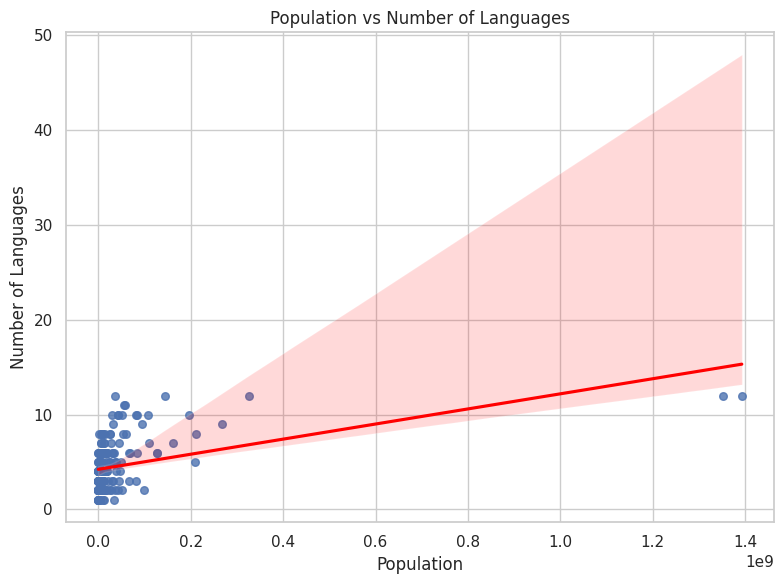

In [ ]:
sns.set(style="whitegrid")

# Population vs Number of Languages
plt.figure(figsize=(8, 6))
sns.regplot(data=merged_df, x='population', y='number_of_languages', scatter_kws={"s": 30}, line_kws={"color": "red"})
plt.title('Population vs Number of Languages')
plt.xlabel('Population')
plt.ylabel('Number of Languages')
plt.tight_layout()
plt.show()

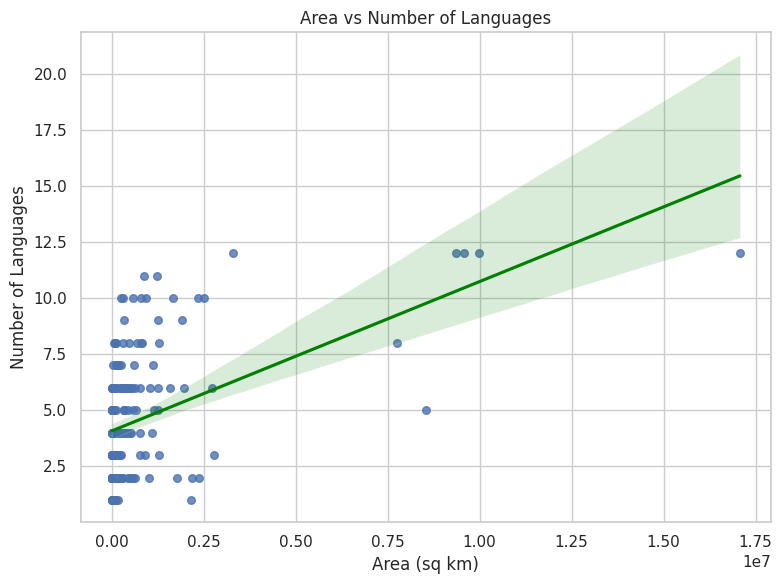

In [ ]:
# Area vs Number of Languages
plt.figure(figsize=(8, 6))
sns.regplot(data=merged_df, x='area', y='number_of_languages', scatter_kws={"s": 30}, line_kws={"color": "green"})
plt.title('Area vs Number of Languages')
plt.xlabel('Area (sq km)')
plt.ylabel('Number of Languages')
plt.tight_layout()
plt.show()

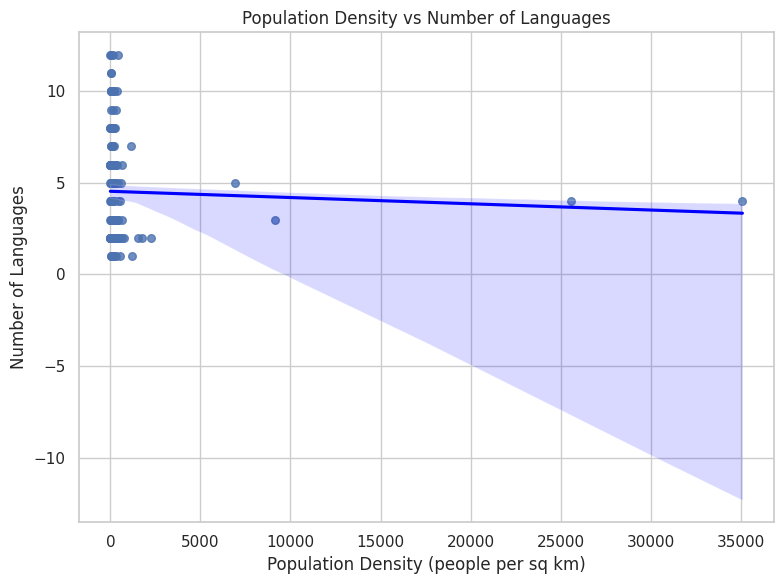

In [ ]:
# Population Density vs Number of Languages
plt.figure(figsize=(8, 6))
sns.regplot(data=merged_df, x='population_density', y='number_of_languages', scatter_kws={"s": 30}, line_kws={"color": "blue"})
plt.title('Population Density vs Number of Languages')
plt.xlabel('Population Density (people per sq km)')
plt.ylabel('Number of Languages')
plt.tight_layout()
plt.show()

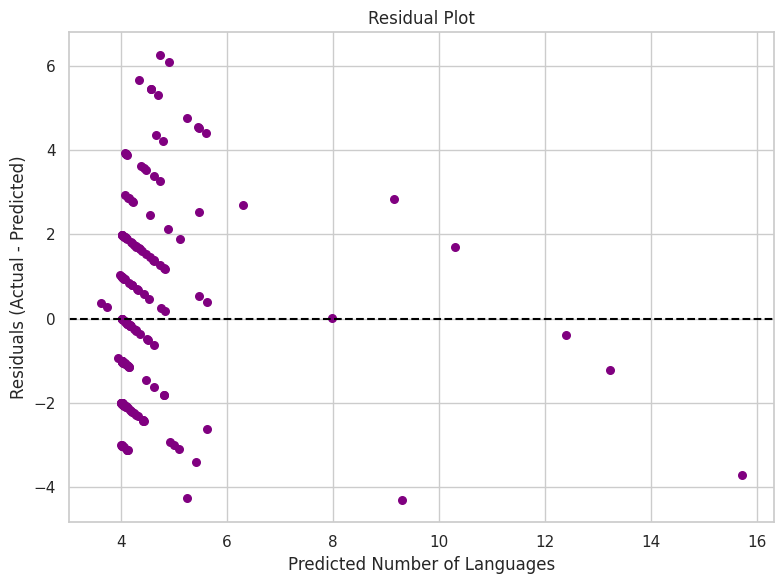

In [ ]:
# Residual Plot
y_pred = model.predict(X)

residuals = y - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='purple', s=30)
plt.axhline(0, linestyle='--', color='black')
plt.title('Residual Plot')
plt.xlabel('Predicted Number of Languages')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()

From these models there is a lot to learn about the dataset and the conclusions that we may or may not be able to make from our regression estimate.
First of all, just from quickly glancing at the visuals we can see that a lot of the data is heavily clustered in one corner of the graph. This is because there a skew towards low area, less populated countries than large area, heavily populated countries. These smaller countries are a lot tougher to predict because there is such a large range in their number of languages yet a much smaller range  relatively to population and area between them.

These scatter plots reinforce what we observed from our regression metrics. There are general trends, but they are not strong enough to yield accurate predictions for most countries. The visuals also highlight the need for potential feature transformations such as log-scaling population or area, or potentially including other variables like geographic isolation, colonization history, or education levels. Additionally, the residual plot demostrates that it is difficult to predict accurately based on the data provided, further demonstrating the lack of a strong trend within the data for the models to follow.

#6. Contribution Report
For the project, we worked together to create a report which looks to answer questions about a dataset which we found most interesting. In completing the project, Zarko contributed to choosing the questions which would be answered, gathering and modifying the data for use in data analysis, performing K-Fold cross validation, and interpreting the results of the analysis (From the graphics prepared by others in the group). Eric contributed in providing multiple different research questions for the project, assisting Zarko with modifying the data, setting up the dockerfile and files on GitHub, and explaining what we did to clean and prepare the data for the analysis. Jameson contributed in the interpretation of results, merging the datasets, as well as the visuals associated with them and parts of the code. Becky contributed to gathering the data with Zarko, as well as some parts of the interpreting of the results.